# Data Preprocessing Lab: Getting Data ML-Ready

## Student Practice Notebook

**Name:** ______Tejaswini Kanike________________  
**Register Number:** ____AP24110010714__________________  
**Date:** __________22/08/2026____________  

## Learning Objectives

After completing this lab, you will be able to:

- Handle missing data with justified strategies (not just delete-everything)
- Encode categorical variables into numeric form (label encoding, one-hot encoding)
- Scale/normalize numeric features (min-max scaling, standardization)
- Detect and handle outliers
- Split data into train/test sets correctly
- Apply preprocessing to image data (pixel normalization) and text data (numeric encoding)

### Why this week matters
Every ML model needs **numbers, on a similar scale, with no gaps**. Raw pandas data (mixed types, missing values, unscaled numbers) can't go directly into a model. This lab is the bridge between "clean data" (last week) and "model-ready data" (next steps in your course).

### How to use this notebook
Same as before: **demo → practice → predict-then-run → reflect.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)
tips['tip_pct'] = tips['tip'] / tips['total_bill']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147


## Part 1: Missing Data — Choosing a Strategy

Last week you dropped or filled missing values without much thought about *which* to choose. This week: which strategy is right depends on the situation.

### Demonstration


In [2]:
tips_missing = tips.copy()
np.random.seed(42)
missing_idx = np.random.choice(tips_missing.index, size=15, replace=False)
tips_missing.loc[missing_idx, 'total_bill'] = np.nan

print("Missing values:", tips_missing['total_bill'].isna().sum())
print("Percentage missing: {:.1f}%".format(100 * tips_missing['total_bill'].isna().sum() / len(tips_missing)))


Missing values: 15
Percentage missing: 6.1%


**Common strategies:**
- **Drop rows** — safe when missing % is small AND rows are random (not systematically missing)
- **Fill with mean/median** — good for numeric columns; median is safer when outliers exist
- **Fill with mode** — for categorical columns
- **Fill with group-wise mean** — smarter: fill using the mean *within a relevant group* instead of the global mean

### Demonstration: group-wise fill (smarter than global mean)


In [3]:
# Instead of filling with the overall mean, fill using each day's own mean
# This preserves day-to-day differences instead of flattening everything to one number

day_means = tips_missing.groupby('day')['total_bill'].transform('mean')
tips_filled = tips_missing.copy()
tips_missing_filled_bill = tips_missing['total_bill'].fillna(day_means)
tips_filled['total_bill'] = tips_missing_filled_bill

print("Remaining missing:", tips_filled['total_bill'].isna().sum())


Remaining missing: 0


### Student Practice

1. Create missing values in the `tip` column (5 random rows) the same way as the demo.
2. Fill them using the **median** `tip` grouped by `time` (Lunch/Dinner) instead of by day.
3. In 1-2 sentences, justify why you chose group-by-`time` over a global fill for this column.


In [5]:

df_missing = tips.copy()

# 1
random_rows = df_missing.sample(n=5, random_state=42).index
df_missing.loc[random_rows, 'tip'] = np.nan

# 2
df_missing['tip'] = df_missing.groupby('time')['tip'].transform(
    lambda x: x.fillna(x.median())
)

df_missing

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059
1,10.34,1.66,Male,No,Sun,Dinner,3,0.161
2,21.01,3.50,Male,No,Sun,Dinner,3,0.167
3,23.68,3.31,Male,No,Sun,Dinner,2,0.140
4,24.59,3.61,Female,No,Sun,Dinner,4,0.147
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.204
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0.074
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.088
242,17.82,1.75,Male,No,Sat,Dinner,2,0.098


3.Grouping by time is better than using one global median because Lunch and Dinner may have different tipping patterns. This preserves differences between the two time categories while filling the missing values.

**Reflection:** Why might filling missing values with a *group-wise* mean/median be better than a single global mean? Give a concrete scenario where this would matter.

*Your answer:*
Group-wise mean or median can be better because different groups may have different typical values. For example, Lunch and Dinner may have different tipping patterns, so filling missing tip values with the median for the corresponding time group preserves those differences better than using one global value.

## Part 2: Encoding Categorical Variables

ML models need numbers — they can't use `"Male"`, `"Sun"`, `"Yes"` directly. We need to **encode** categories into numeric form.

### 2a. Label Encoding (for ordinal/binary categories)

### Demonstration


In [6]:
tips_enc = tips.copy()

# Binary categories: map directly to 0/1
tips_enc['sex_encoded'] = tips_enc['sex'].map({'Male': 0, 'Female': 1})
tips_enc['smoker_encoded'] = tips_enc['smoker'].map({'No': 0, 'Yes': 1})

tips_enc[['sex','sex_encoded','smoker','smoker_encoded']].head()


,sex,sex_encoded,smoker,smoker_encoded
0,Female,1,No,0
1,Male,0,No,0
2,Male,0,No,0
3,Male,0,No,0
4,Female,1,No,0


### 2b. One-Hot Encoding (for categories with no natural order)

`day` has 4 categories with no inherent ranking (Thur isn't "less than" Fri). Label encoding (0,1,2,3) would wrongly imply an order. **One-hot encoding** creates a separate 0/1 column per category instead.

### Demonstration


In [7]:
day_dummies = pd.get_dummies(tips_enc['day'], prefix='day')
tips_enc = pd.concat([tips_enc, day_dummies], axis=1)
tips_enc[['day','day_Thur','day_Fri','day_Sat','day_Sun']].head()


,day,day_Thur,day_Fri,day_Sat,day_Sun
0,Sun,False,False,False,True
1,Sun,False,False,False,True
2,Sun,False,False,False,True
3,Sun,False,False,False,True
4,Sun,False,False,False,True


### Student Practice — predict then check

`time` has 2 categories (Lunch, Dinner). Predict: should you use label encoding or one-hot encoding for `time`, and why? Write your prediction, then implement whichever you chose.

*Your prediction:*use one-hot encoding because time is a nominal categorical variable—Lunch and Dinner have no natural numerical order. One-hot encoding avoids implying that one category is greater than the other.


In [8]:
# Write your answer here
tips_encoded = pd.get_dummies(tips, columns=['time'], dtype=int)

tips_encoded.head()

,total_bill,tip,sex,smoker,day,size,tip_pct,time_Dinner,time_Lunch
0,16.99,1.01,Female,No,Sun,2,0.059,1,0
1,10.34,1.66,Male,No,Sun,3,0.161,1,0
2,21.01,3.50,Male,No,Sun,3,0.167,1,0
3,23.68,3.31,Male,No,Sun,2,0.140,1,0
4,24.59,3.61,Female,No,Sun,4,0.147,1,0


**Reflection:** Why would label-encoding `day` as Thur=0, Fri=1, Sat=2, Sun=3 be misleading to a model, even though it's technically valid Python code?

*Your answer:*
Label-encoding day as Thur=0, Fri=1, Sat=2, Sun=3 can be misleading because the numbers suggest an artificial order and numerical relationship between the days. For example, a model might interpret Sun (3) as greater than Thur (0), even though the categories do not have a meaningful ranking.

## Part 3: Feature Scaling

`total_bill` ranges roughly 3-50, while `tip_pct` ranges roughly 0-1. Many ML algorithms (e.g. distance-based ones like KNN, or gradient-based ones) perform poorly when features are on very different scales — a large-range feature can dominate just because of its scale, not because it's more important.

### 3a. Min-Max Scaling (rescales to a fixed 0-1 range)

### Demonstration


In [9]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

tips_enc['total_bill_scaled'] = min_max_scale(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_scaled']].describe()


,total_bill,total_bill_scaled
count,244.000,244.000
mean,19.786,0.350
std,8.902,0.186
min,3.070,0.000
25%,13.348,0.215
50%,17.795,0.308
75%,24.127,0.441
max,50.810,1.000


### 3b. Standardization (rescales to mean=0, std=1)

### Demonstration


In [10]:
def standardize(series):
    return (series - series.mean()) / series.std()

tips_enc['total_bill_standardized'] = standardize(tips_enc['total_bill'])
tips_enc[['total_bill','total_bill_standardized']].describe()


,total_bill,total_bill_standardized
count,244.000,2.440e+02
mean,19.786,-6.029e-17
std,8.902,1.000e+00
min,3.070,-1.878e+00
25%,13.348,-7.232e-01
50%,17.795,-2.236e-01
75%,24.127,4.877e-01
max,50.810,3.485e+00


### Student Practice — predict then check

Predict: after standardizing, what will the **mean** of `total_bill_standardized` be (approximately)? What about the standard deviation? Write your prediction, then verify with `.mean()` and `.std()`.

*Your prediction:*


The mean of total_bill_standardized should be approximately 0, and the standard deviation should be approximately 1 after standardization.


In [11]:
# Write your answer here
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
tips['total_bill_standardized'] = scaler.fit_transform(
    tips[['total_bill']]
)

print("Mean:", tips['total_bill_standardized'].mean())
print("Standard deviation:", tips['total_bill_standardized'].std())

minmax_scaler = MinMaxScaler()
tips['size_scaled'] = minmax_scaler.fit_transform(
    tips[['size']]
)

tips[['size', 'size_scaled']].head()

Mean: -7.871663248366888e-17
Standard deviation: 1.0020555006273097


,size,size_scaled
0,2,0.2
1,3,0.4
2,3,0.4
3,2,0.2
4,4,0.6


**Reflection:** In your own words, what's the difference between min-max scaling and standardization? When might you prefer one over the other? (Hint: think about what happens to each with extreme outliers.)

*Your answer:*
Min-max scaling changes values to a fixed range, usually 0 to 1, while standardization changes values so they are centered around 0 with a standard deviation of 1. I would prefer standardization when there are extreme outliers because min-max scaling is more strongly affected by very large or small values.

## Part 4: Outlier Detection and Handling

Outliers are unusually extreme values that can distort model training. A common rule: values beyond **1.5 × IQR** (interquartile range) from Q1/Q3 are considered outliers.

### Demonstration


In [12]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Number of outliers: {len(outliers)}")
outliers[['total_bill','day','size']]


Bounds: [-2.82, 40.30]
Number of outliers: 9


,total_bill,day,size
59,48.27,Sat,4
102,44.30,Sat,3
142,41.19,Thur,5
156,48.17,Sun,6
170,50.81,Sat,3
182,45.35,Sun,3
184,40.55,Sun,2
197,43.11,Thur,4
212,48.33,Sat,4


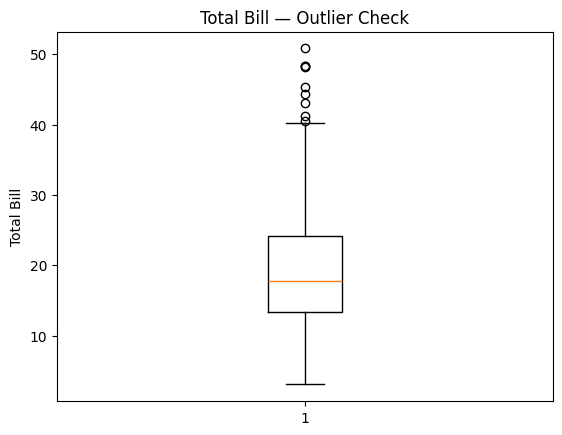

In [13]:
# Visualize outliers with a boxplot
plt.figure()
plt.boxplot(tips['total_bill'])
plt.title("Total Bill — Outlier Check")
plt.ylabel("Total Bill")
plt.show()


### Student Practice

1. Run the same IQR outlier check on the `tip` column.
2. Instead of dropping outliers, **cap** them: replace any value above `upper_bound` with `upper_bound` itself, and any value below `lower_bound` with `lower_bound` (this is called "capping" or "winsorizing" — it keeps the row but limits the extreme value).


In [14]:
# Write your answer here


Q1 = tips['tip'].quantile(0.25)
Q3 = tips['tip'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)


outliers = tips[
    (tips['tip'] < lower_bound) |
    (tips['tip'] > upper_bound)
]

print("Number of outliers:", len(outliers))


tips['tip_capped'] = tips['tip'].clip(
    lower=lower_bound,
    upper=upper_bound
)


tips[['tip', 'tip_capped']].head()

Lower bound: -0.34375
Upper bound: 5.90625
Number of outliers: 9


,tip,tip_capped
0,1.01,1.01
1,1.66,1.66
2,3.50,3.50
3,3.31,3.31
4,3.61,3.61


**Reflection:** Why might capping outliers be preferable to simply dropping those rows? When would dropping be the better choice instead?

*Your answer:*
Capping outliers is useful because it keeps all rows and reduces the effect of extreme values without losing data. Dropping rows may be better when the outliers are clearly caused by data-entry errors or incorrect measurements.

## Part 5: Train/Test Split

Before training any model, data must be split so we can test performance on data the model has never seen. Splitting **after** all the preprocessing above ensures both sets are equally clean and encoded.

### Demonstration


In [15]:
from sklearn.model_selection import train_test_split

X = tips_enc[['total_bill_scaled','size','sex_encoded','smoker_encoded']]
y = tips_enc['tip_pct']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (195, 4)
Test shape: (49, 4)


### Student Practice

1. Redo the split with `test_size=0.3` instead of 0.2. How many rows end up in the test set now?
2. Why do we set `random_state=42` (or any fixed number)? What would change if you removed it and ran the split twice?


In [16]:
# Write your answer here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set rows:", X_train.shape[0])
print("Test set rows:", X_test.shape[0])


Training set rows: 170
Test set rows: 74


**Reflection:** Why is it important to split data **before** the model ever sees the test set, rather than training on all the data at once?

*Your answer:*
Splitting the data first helps us test the model on unseen data and measure how well it generalizes. If we train on all the data, the model may memorize the test data, so its performance would not be a reliable measure of how well it works on new data.


# Mini Project A: Image Preprocessing Pipeline (Image Track)

Raw image pixel values (0-255) are rarely fed directly into a model — they're almost always normalized first. You'll now apply real preprocessing to the images from your Week 2 mini-project.

## Step 1: Normalize pixel values

### Demonstration


In [17]:
from google.colab import files
uploaded = files.upload()


Saving wallpaper.jpg to wallpaper.jpg


In [18]:
from PIL import Image
import numpy as np

filenames = list(uploaded.keys())
sample_name = filenames[0]
img_array = np.array(Image.open(sample_name))

print("Original pixel range:", img_array.min(), "-", img_array.max())
print("Original dtype:", img_array.dtype)

# Normalize to 0-1 range (standard preprocessing step before feeding into a CNN)
img_normalized = img_array / 255.0

print("Normalized pixel range:", img_normalized.min(), "-", img_normalized.max())
print("Normalized dtype:", img_normalized.dtype)


Original pixel range: 0 - 255
Original dtype: uint8
Normalized pixel range: 0.0 - 1.0
Normalized dtype: float64


### Student Practice

1. Normalize **all** your uploaded images (loop over `filenames`) and store each normalized array in a list.
2. Build a small pandas DataFrame with columns `filename`, `min_pixel_before`, `max_pixel_before`, `min_pixel_after`, `max_pixel_after` to confirm normalization worked correctly across all images.


In [19]:
# Write your answer here
import numpy as np
import pandas as pd

normalized_images = []
results = []

for filename in filenames:
    image = np.array(Image.open(filename))

    min_before = image.min()
    max_before = image.max()

    normalized_image = image.astype(float) / 255.0
    normalized_images.append(normalized_image)

    min_after = normalized_image.min()
    max_after = normalized_image.max()

    results.append({
        "filename": filename,
        "min_pixel_before": min_before,
        "max_pixel_before": max_before,
        "min_pixel_after": min_after,
        "max_pixel_after": max_after
    })


normalization_df = pd.DataFrame(results)

normalization_df


,filename,min_pixel_before,max_pixel_before,min_pixel_after,max_pixel_after
0,wallpaper.jpg,0,255,0.0,1.0


## Step 2: Resize images to a consistent shape

Models need every input image to be the **same size**. Your uploaded images likely have different dimensions. Resizing standardizes this.

### Demonstration


In [20]:
target_size = (128, 128)

img_pil = Image.open(sample_name)
img_resized = img_pil.resize(target_size)
img_resized_array = np.array(img_resized)

print("Original shape:", img_array.shape)
print("Resized shape:", img_resized_array.shape)


Original shape: (2016, 3787, 3)
Resized shape: (128, 128, 3)


### Student Practice

Resize all your uploaded images to `(128, 128)`, normalize each to 0-1, and confirm every resulting array has the exact same shape using a pandas DataFrame (columns: `filename`, `shape`).


In [21]:
# Write your answer here
from PIL import Image
import numpy as np
import pandas as pd

processed_images = []
results = []

for filename in filenames:

    image = Image.open(filename)

    image = image.resize((128, 128))

    image_array = np.array(image).astype(float) / 255.0

    processed_images.append(image_array)

    results.append({
        "filename": filename,
        "shape": image_array.shape
    })

shape_df = pd.DataFrame(results)

shape_df

,filename,shape
0,wallpaper.jpg,"(128, 128, 3)"


**Reflection:** Why must every image fed into a model have the exact same shape? What would happen if you tried to feed images of different sizes into the same model?

*Your answer:*
Every image must have the same shape so the model receives a consistent number of input values and can process all images in the same way. If images have different sizes, they cannot usually be combined into one batch or passed through the same fixed-size model input without resizing or padding.

# Mini Project B: Text Preprocessing Pipeline (NLP Track)

Just like images, raw text needs preprocessing before a model can use it: cleaning, and converting words into numeric IDs (since bag-of-words counts alone aren't how most modern NLP pipelines represent text).

## Step 1: Text cleaning

### Demonstration


In [22]:
raw_text = "NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day."

# Cleaning steps: lowercase, remove punctuation, tokenize
import re

cleaned = raw_text.lower()
cleaned = re.sub(r'[^a-z0-9\s]', '', cleaned)  # remove punctuation
tokens = cleaned.split()

print("Before:", raw_text)
print("After:", tokens)


Before: NumPy, Pandas, and Scikit-Learn are AMAZING tools!!! I use NumPy every day.
After: ['numpy', 'pandas', 'and', 'scikitlearn', 'are', 'amazing', 'tools', 'i', 'use', 'numpy', 'every', 'day']


### Student Practice

Write your own messy sentence (include punctuation, capital letters, maybe a number). Clean it using the same pattern and print the resulting tokens.


In [23]:
# Write your answer here
import re

sentence = "This is an ML course!"

sentence = sentence.lower()
cleaned_text = re.sub(r'[^a-z\s]', '', sentence)
tokens = cleaned_text.split()

print(tokens)

['this', 'is', 'an', 'ml', 'course']


## Step 2: Encoding words as numeric IDs

Models need numbers, not words. We'll build a **word-to-ID mapping** (a simple form of what's called a "vocabulary index" — the first step toward embeddings).

### Demonstration


In [24]:
vocabulary = sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocabulary)}

print("Word to ID mapping:", word_to_id)

encoded_tokens = [word_to_id[word] for word in tokens]
print("Original tokens:", tokens)
print("Encoded as IDs:  ", encoded_tokens)


Word to ID mapping: {'an': 0, 'course': 1, 'is': 2, 'ml': 3, 'this': 4}
Original tokens: ['this', 'is', 'an', 'ml', 'course']
Encoded as IDs:   [4, 2, 0, 3, 1]


### Student Practice

1. Build a `word_to_id` mapping for the tokens from your Step 1 sentence.
2. Encode your tokens into a list of numeric IDs.
3. Build a pandas DataFrame with columns `word` and `id` showing the full mapping, sorted by `id`.


In [25]:
# Write your answer here
import pandas as pd

tokens = ['this', 'is', 'an', 'ml', 'course']

# 1
word_to_id = {word: i for i, word in enumerate(tokens)}

# 2
encoded_tokens = [word_to_id[word] for word in tokens]

print("Word to ID:", word_to_id)
print("Encoded tokens:", encoded_tokens)

# 3
mapping_df = pd.DataFrame(
    list(word_to_id.items()),
    columns=['word', 'id']
).sort_values('id')

mapping_df

Word to ID: {'this': 0, 'is': 1, 'an': 2, 'ml': 3, 'course': 4}
Encoded tokens: [0, 1, 2, 3, 4]


,word,id
0,this,0
1,is,1
2,an,2
3,ml,3
4,course,4


**Reflection:** This word-to-ID encoding is similar to label encoding from Part 2. What potential problem could this cause if fed directly into a model (Hint: think about the "misleading order" issue from Part 2 — does the same issue apply to words)?

*Your answer:*
Word-to-ID encoding can create a misleading order because the numbers assigned to words do not have any real meaning. For example, the model might think that course = 4 is greater than this = 0, even though there is no meaningful relationship between the words.

# Final Self-Check

- [ ] I handled missing data using a justified strategy, not just dropped everything blindly
- [ ] I correctly chose label encoding vs one-hot encoding based on whether categories have order
- [ ] I scaled numeric features and can explain the difference between min-max and standardization
- [ ] I detected outliers using IQR and handled them (capped, not just deleted)
- [ ] I split data into train/test sets correctly
- [ ] I completed Mini Project A (image normalization/resizing) or B (text cleaning/encoding)
- [ ] I answered all reflection questions in my own words

## Final Reflection Questions

1. Put the preprocessing steps in this lab in the order you'd typically apply them to a raw dataset, and briefly justify the order.

2. Why is preprocessing considered part of "data work," and not something a model does automatically?

3. Compare preprocessing images (Mini Project A) vs preprocessing text (Mini Project B). What's conceptually similar between normalizing pixels and encoding words as IDs?

4. What's one preprocessing concept from this lab you still feel unsure about? Be specific.


1. Preprocessing order

First, I would clean the data, then handle missing values and outliers, then encode categorical/text data, and finally scale or normalize numerical data. This order helps make the data clean and consistent before giving it to a machine learning model.

2. Why preprocessing is data work

Preprocessing is part of data work because the model cannot automatically know how to handle missing values, different scales, text, or inconsistent formats correctly. We need to prepare the data so the model can understand and use it properly.

3. Images vs text

Both image and text preprocessing convert raw data into a form that a machine learning model can work with. For images, we normalize pixel values to a common range, while for text, we convert words into numeric IDs so the words can be represented as numbers.

4. Concept I am still unsure about

I am still a little unsure about when to choose standardization versus min-max scaling, especially when the dataset contains extreme outliers.